In [15]:
import sys
sys.path.append("..")
import gymnasium as gym
from gymnasium.wrappers import RecordVideo

env = gym.make("HalfCheetah-v5")

In [16]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
state_dim, action_dim

(17, 6)

In [17]:
import numpy as np
import torch
from src.fnn import FNN
from src.replay_buffer import ReplayBuffer
from src.utils import device, polyak_update
from src.variable_fnn import VariableFNN
from torch import nn, optim

rng = np.random.default_rng(0)

actor = FNN(
    input_size = state_dim,
    hidden_size = 256,
    num_hidden_layers = 5,
    output_size = action_dim + action_dim * (action_dim + 1) // 2,
).to(device)

critic = FNN(
    input_size = state_dim + action_dim,
    hidden_size = 256,
    num_hidden_layers = 5,
    output_size = 1,
).to(device)

target_actor = FNN(
    input_size = state_dim,
    hidden_size = 256,
    num_hidden_layers = 5,
    output_size = action_dim + action_dim * (action_dim + 1) // 2,
).to(device)

target_critic = FNN(
    input_size = state_dim + action_dim,
    hidden_size = 256,
    num_hidden_layers = 5,
    output_size = 1,
).to(device)

target_actor.load_state_dict(actor.state_dict())
for param in target_actor.parameters():
    param.requires_grad_(False)
target_critic.load_state_dict(critic.state_dict())
for param in target_critic.parameters():
    param.requires_grad_(False)


In [ ]:
from tqdm import trange
from torch.distributions import MultivariateNormal
from torch.nn.functional import mse_loss
from torch.nn.utils import clip_grad_norm_

num_episodes = 300
batch_size = 128
replay_capacity = 100000
gamma = 0.99
actor_lr = 3e-4
critic_lr = 3e-4
actor_polyak = 0.005
critic_polyak = 0.005
actor_update_interval = 1
update_every_steps = 10
max_grad_norm = .5
# alpha = 0.5
# alpha_decay = 0.9999
# alpha_min = 0.01

actor_optimizer = optim.Adam(actor.parameters(), lr = actor_lr)
critic_optimizer = optim.Adam(critic.parameters(), lr = critic_lr)

replay_buffer = ReplayBuffer(
    capacity = replay_capacity,
    batch_size = batch_size,
    device = device,
    rng = rng,
)

def get_multivariate_normal(params):
    loc = params[:, : action_dim]
    scale = params[:, action_dim :]
    L = torch.zeros(params.shape[0], action_dim, action_dim, device = device)
    tril_indices = torch.tril_indices(row = action_dim, col = action_dim)
    L[:, tril_indices[0], tril_indices[1]] = scale
    L_diag = L.diagonal(dim1 = -2, dim2 = -1)
    L_diag[:] = torch.exp(L_diag)
    return MultivariateNormal(loc, scale_tril = L)

# action_low = torch.tensor(env.action_space.low, dtype = torch.float32, device = device)
# action_high = torch.tensor(env.action_space.high, dtype = torch.float32, device = device)
iter_count = 0
update_count = 0
episode_rewards = []
for episode in trange(num_episodes):
    done = False
    episode_reward = 0
    state, _ = env.reset()

    while not done:
        with torch.no_grad():
            state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
            policy_params = actor(state)
            policy = get_multivariate_normal(policy_params)
            action = torch.tanh(policy.sample())

        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        episode_reward += reward
        done = terminated or truncated
        replay_buffer.add((
            state,
            action,
            torch.tensor([[reward]], dtype = torch.float32),
            torch.tensor([[done]], dtype = torch.int32),
            torch.tensor([next_state], dtype = torch.float32),
        ))

        if iter_count % update_every_steps == 0 and replay_buffer.ready():
            batch_state, batch_action, batch_reward, batch_done,batch_next_state = replay_buffer.sample()
            
            critic_optimizer.zero_grad(set_to_none = True)
            with torch.no_grad():
                next_policy_params = target_actor(batch_next_state)
                next_policy = get_multivariate_normal(next_policy_params)
                next_action = torch.tanh(next_policy.sample())
                next_log_prob = next_policy.log_prob(next_action).unsqueeze(1)
                next_q = target_critic(torch.cat([batch_next_state, next_action], dim = 1))
                target_q = batch_reward + gamma * (1 - batch_done) * (next_q - alpha * next_log_prob)
            q = critic(torch.cat([batch_state, batch_action], dim = 1))
            critic_loss = mse_loss(q, target_q)
            critic_loss.backward()
            clip_grad_norm_(critic.parameters(), max_grad_norm)
            critic_optimizer.step()
            polyak_update(critic, target_critic, critic_polyak)

            actor_optimizer.zero_grad(set_to_none = True)
            policy_params = actor(batch_state)
            policy = get_multivariate_normal(policy_params)
            action = torch.tanh(policy.rsample())
            log_prob = policy.log_prob(action).unsqueeze(1)
            with torch.no_grad():
                q = critic(torch.cat([batch_state, action], dim = 1))
            actor_loss = (alpha * log_prob - q).mean()
            actor_loss.backward()
            clip_grad_norm_(actor.parameters(), max_grad_norm)
            actor_optimizer.step()
            polyak_update(actor, target_actor, actor_polyak)

            if update_count % 100 == 0:
                print(f"{update_count}, al: {actor_loss.item():.8f}, cl: {critic_loss.item():.8f}, er: {episode_rewards[-1] if episode_rewards else 0:.8f}, ap: {alpha:.8f}")
            alpha = max(alpha * alpha_decay, alpha_min)
            update_count += 1

        state = next_state
        iter_count += 1
    
    episode_rewards.append(episode_reward)

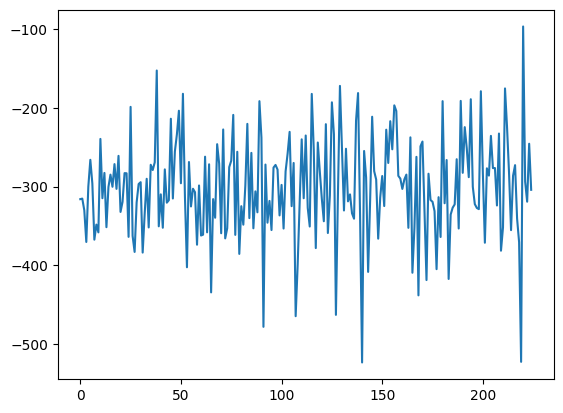

In [49]:
import matplotlib.pyplot as plt
plt.plot(episode_rewards)
plt.show()

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from tqdm import trange
from src.fnn import FNN


# Hyperparameters
num_episodes     = 1000
gamma            = 0.99
actor_lr         = 3e-4
critic_lr        = 1e-3
entropy_coef     = 0.01
max_grad_norm    = 0.5
device           = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = gym.make("HalfCheetah-v4", max_episode_steps=500)
state_dim  = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_low  = torch.tensor(env.action_space.low,  dtype=torch.float32, device=device)
action_high = torch.tensor(env.action_space.high, dtype=torch.float32, device=device)

# Actor outputs mean and log_std
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self._net = FNN(
            input_size=state_dim,
            hidden_size=256,
            num_hidden_layers=3,
            output_size=action_dim,
        )
        self._log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, x):
        mean = self._net(x)
        std  = self._log_std.exp().expand_as(mean)
        return torch.distributions.Normal(mean, std)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self._net = FNN(
            input_size=state_dim,
            hidden_size=256,
            num_hidden_layers=3,
            output_size=1,
        )

    def forward(self, x):
        return self._net(x).squeeze(-1)


actor  = Actor().to(device)
critic = Critic().to(device)

actor_optimizer  = optim.Adam(actor.parameters(),  lr=actor_lr)
critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

episode_rewards = []

for episode in trange(num_episodes):
    state_np, _ = env.reset(seed=episode)
    state = torch.tensor(state_np, dtype=torch.float32, device=device)

    log_probs, values, rewards, entropies = [], [], [], []
    terminated = truncated = False

    # ── Rollout ──────────────────────────────────────────────────────────
    while not terminated and not truncated:
        dist   = actor(state.unsqueeze(0))
        action = dist.sample()
        action_clipped = action.clamp(action_low, action_high)

        log_prob = dist.log_prob(action).sum(-1)      # sum over action dims
        entropy  = dist.entropy().sum(-1)
        value    = critic(state.unsqueeze(0))

        next_state_np, reward, terminated, truncated, _ = env.step(
            action_clipped[0].detach().cpu().numpy()
        )

        log_probs.append(log_prob)
        values.append(value)
        rewards.append(float(reward))
        entropies.append(entropy)

        state = torch.tensor(next_state_np, dtype=torch.float32, device=device)

    # ── Compute returns ───────────────────────────────────────────────────
    # Bootstrap from last state if not truly terminal
    with torch.no_grad():
        last_value = 0.0 if terminated else critic(state.unsqueeze(0)).item()

    returns = []
    R = last_value
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)

    returns    = torch.tensor(returns,  dtype=torch.float32, device=device)
    values_t   = torch.cat(values,      dim=0)
    log_probs_t = torch.stack(log_probs)
    entropies_t = torch.stack(entropies)

    advantages = returns - values_t.detach()   # detached — no critic grads into actor

    # ── Critic update ─────────────────────────────────────────────────────
    critic_loss = (returns - values_t).pow(2).mean()
    critic_optimizer.zero_grad(set_to_none=True)
    critic_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), max_grad_norm)
    critic_optimizer.step()

    # ── Actor update ──────────────────────────────────────────────────────
    actor_loss = -(log_probs_t * advantages).mean() - entropy_coef * entropies_t.mean()
    actor_optimizer.zero_grad(set_to_none=True)
    actor_loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), max_grad_norm)
    actor_optimizer.step()

    episode_reward = sum(rewards)
    episode_rewards.append(episode_reward)

    if (episode + 1) % 10 == 0:
        mean_10 = np.mean(episode_rewards[-10:])
        print(f"Episode {episode+1:4d} | reward {episode_reward:8.1f} | mean-10 {mean_10:8.1f} "
              f"| critic_loss {critic_loss.item():.4f}")

episode_rewards[-10:]

c:\Users\abhay\anaconda3\envs\ursa25\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
  0%|          | 1/1000 [00:08<2:28:12,  8.90s/it]


KeyboardInterrupt: 

In [27]:
from tqdm import trange
from torch.distributions import MultivariateNormal
from torch.nn.functional import mse_loss
from torch.nn.utils import clip_grad_norm_

num_episodes = 100000
batch_size = 128
replay_capacity = 100000
gamma = 0.99
actor_lr = 3e-4
critic_lr = 3e-4
actor_polyak = 0.0001
critic_polyak = 0.005
actor_update_interval = 1
update_every_steps = 20
max_grad_norm = 0.5
alpha = 0.5
alpha_decay = 0.9999
alpha_min = 0.01
tanh_scale = 7

actor_optimizer = optim.Adam(actor.parameters(), lr = actor_lr)
critic_optimizer = optim.Adam(critic.parameters(), lr = critic_lr)

replay_buffer = ReplayBuffer(
    capacity = replay_capacity,
    batch_size = batch_size,
    device = device,
    rng = rng,
)

def get_bradley_terry_loss(q1, q2, log_prob1, log_prob2):
    with torch.no_grad():
        weight = abs(q1 - q2)
        weight += weight.std() / 10
    log_prob_diff = log_prob1 - log_prob2
    log_prob_contrast = torch.where(q1 > q2, log_prob_diff, -log_prob_diff)
    return -(weight * torch.log(torch.sigmoid(log_prob_contrast) + 1e-6)).mean() / (weight.mean() + 1e-6), log_prob_contrast.mean().item()


def get_multivariate_normal(params):
    loc = params[:, : action_dim]
    scale = params[:, action_dim :]
    L = torch.zeros(params.shape[0], action_dim, action_dim, device = device)
    tril_indices = torch.tril_indices(row = action_dim, col = action_dim)
    L[:, tril_indices[0], tril_indices[1]] = scale
    L_diag = L.diagonal(dim1 = -2, dim2 = -1)
    L_diag[:] = torch.exp(L_diag)
    return MultivariateNormal(loc, scale_tril = L)

# action_low = torch.tensor(env.action_space.low, dtype = torch.float32, device = device)
# action_high = torch.tensor(env.action_space.high, dtype = torch.float32, device = device)
iter_count = 0
update_count = 0
episode_rewards = []
for episode in trange(num_episodes):
    done = False
    episode_reward = 0
    state, _ = env.reset()

    while not done:
        with torch.no_grad():
            state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
            policy_params = actor(state)
            policy = get_multivariate_normal(policy_params)
            action = torch.tanh(policy.sample() / tanh_scale)

        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        episode_reward += reward
        done = terminated or truncated
        replay_buffer.add((
            state,
            action,
            torch.tensor([[reward]], dtype = torch.float32),
            torch.tensor([[done]], dtype = torch.int32),
            torch.tensor([next_state], dtype = torch.float32),
        ))

        if iter_count % update_every_steps == 0 and replay_buffer.ready():
            batch_state, batch_action, batch_reward, batch_done,batch_next_state = replay_buffer.sample()
            
            critic_optimizer.zero_grad(set_to_none = True)
            with torch.no_grad():
                next_policy_params = target_actor(batch_next_state)
                next_policy = get_multivariate_normal(next_policy_params)
                next_action = torch.tanh(next_policy.sample() / tanh_scale)
                next_q = target_critic(torch.cat([batch_next_state, next_action], dim = 1))
                target_q = batch_reward + gamma * (1 - batch_done) * next_q
            q = critic(torch.cat([batch_state, batch_action], dim = 1))
            critic_loss = mse_loss(q, target_q)
            critic_loss.backward()
            clip_grad_norm_(critic.parameters(), max_grad_norm)
            critic_optimizer.step()
            polyak_update(target_critic, critic, critic_polyak)
            
            actor_optimizer.zero_grad(set_to_none = True)
            policy_params = actor(batch_state)
            policy = get_multivariate_normal(policy_params)
            action1 = policy.rsample()
            action2 = policy.rsample()
            log_prob1 = policy.log_prob(action1).unsqueeze(1)
            log_prob2 = policy.log_prob(action2).unsqueeze(1)
            action1 = torch.tanh(action1 / tanh_scale)
            action2 = torch.tanh(action2 / tanh_scale)
            with torch.no_grad():
                q1 = target_critic(torch.cat([batch_state, action1], dim = 1))
                q2 = target_critic(torch.cat([batch_state, action2], dim = 1))
            actor_loss, log_prob_contrast = get_bradley_terry_loss(q1, q2, log_prob1, log_prob2)
            actor_loss.backward()
            clip_grad_norm_(actor.parameters(), max_grad_norm)
            actor_optimizer.step()
            polyak_update(target_actor, actor, actor_polyak)

            if update_count % 100 == 0:
                print(f"{update_count}, al: {actor_loss.item():.8f}, cl: {critic_loss.item():.8f}, er: {episode_rewards[-1] if episode_rewards else 0:.8f}, lpc: {log_prob_contrast:.8f}")
            alpha = max(alpha * alpha_decay, alpha_min)
            update_count += 1

        state = next_state
        iter_count += 1
    
    episode_rewards.append(episode_reward)

  0%|          | 0/100000 [00:00<?, ?it/s]

0, al: 1.40869367, cl: 1.20590460, er: 0.00000000, lpc: -0.24270426


  0%|          | 2/100000 [00:06<85:04:51,  3.06s/it]

100, al: 1.21560907, cl: 1.40943515, er: -229.15376807, lpc: 0.23567745


  0%|          | 4/100000 [00:12<83:33:49,  3.01s/it]

...

2700, al: 0.87006462, cl: 1.36575925, er: -425.24305897, lpc: 0.48116428


  0%|          | 56/100000 [06:01<202:14:02,  7.28s/it]

2800, al: 1.37737930, cl: 1.49195087, er: -320.23952989, lpc: -0.24220118


  0%|          | 57/100000 [06:06<178:30:02,  6.43s/it]


KeyboardInterrupt: 

In [10]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import torch

# 1. Setup the Env with Recording
# Use 'rgb_array' so the wrapper can capture the frames
env = gym.make("HalfCheetah-v5", render_mode="rgb_array")

# Wrap it to save to a specific folder
env_recording = RecordVideo(
    env, 
    video_folder="./target_actor_results",
    episode_trigger=lambda x: True, # Record every episode in this run
    name_prefix="final_eval"
)

def record_stochastic_target_actor(num_episodes=5):    
    for ep in range(num_episodes):
        state, _ = env_recording.reset()
        done = False
        truncated = False
        ep_reward = 0
        
        while not (done or truncated):
            with torch.no_grad():
                # 1. Prepare state tensor
                state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                
                # 2. Get distribution params from the Target Actor
                policy_params = actor(state_t)
                
                # 3. Use your training helper to build the distribution
                policy = get_multivariate_normal(policy_params)
                
                # 4. STOCHASTIC: Sample instead of using the mean
                # We use .sample() here because we don't need gradients for eval
                raw_sample = policy.sample() 
                
                # 5. Apply your specific scaling (c=2, s=7)
                action = torch.tanh(raw_sample / tanh_scale)
            
            # Step the environment
            state, reward, done, truncated, _ = env_recording.step(action[0].cpu().numpy())
            ep_reward += reward
            
        print(f"Stochastic Episode {ep} Finished. Reward: {ep_reward:.2f}")

    env_recording.close()

# Run the stochastic evaluation
record_stochastic_target_actor()

Stochastic Episode 0 Finished. Reward: -363.13
Stochastic Episode 1 Finished. Reward: -288.30
Stochastic Episode 2 Finished. Reward: -307.85
Stochastic Episode 3 Finished. Reward: -245.23
Stochastic Episode 4 Finished. Reward: -282.91


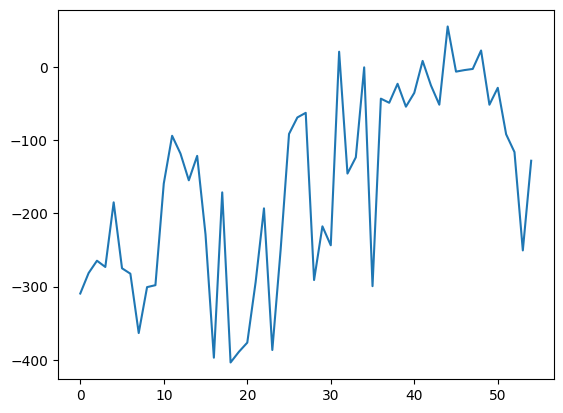

In [24]:
from matplotlib import pyplot as plt

plt.plot(episode_rewards)
plt.show()

In [ ]:
from tqdm import trange
from torch.distributions import MultivariateNormal
from torch.nn.functional import mse_loss
from torch.nn.utils import clip_grad_norm_

num_episodes = 100000
batch_size = 128
replay_capacity = 100000
gamma = 0.99
actor_lr = 3e-4
critic_lr = 3e-4
actor_polyak = 0.005
critic_polyak = 0.005
actor_update_interval = 1
update_every_steps = 20
max_grad_norm = 0.5
alpha = 0.5
alpha_decay = 0.9999
alpha_min = 0.01
tanh_scale = 7

actor_optimizer = optim.Adam(actor.parameters(), lr = actor_lr)
critic_optimizer = optim.Adam(critic.parameters(), lr = critic_lr)

replay_buffer = ReplayBuffer(
    capacity = replay_capacity,
    batch_size = batch_size,
    device = device,
    rng = rng,
)

def get_bradley_terry_loss(q1, q2, log_prob1, log_prob2):
    with torch.no_grad():
        weight = abs(q1 - q2)
        weight += weight.std() / 10
    log_prob_diff = log_prob1 - log_prob2
    log_prob_contrast = torch.where(q1 > q2, log_prob_diff, -log_prob_diff)
    return -(weight * torch.log(torch.sigmoid(log_prob_contrast) + 1e-6)).mean() / (weight.mean() + 1e-6), log_prob_contrast.mean().item()


def get_multivariate_normal(params):
    loc = params[:, : action_dim]
    scale = params[:, action_dim :]
    L = torch.zeros(params.shape[0], action_dim, action_dim, device = device)
    tril_indices = torch.tril_indices(row = action_dim, col = action_dim)
    L[:, tril_indices[0], tril_indices[1]] = scale
    L_diag = L.diagonal(dim1 = -2, dim2 = -1)
    L_diag[:] = torch.exp(L_diag)
    return MultivariateNormal(loc, scale_tril = L)

# action_low = torch.tensor(env.action_space.low, dtype = torch.float32, device = device)
# action_high = torch.tensor(env.action_space.high, dtype = torch.float32, device = device)
iter_count = 0
update_count = 0
episode_rewards = []
for episode in trange(num_episodes):
    done = False
    episode_reward = 0
    state, _ = env.reset()

    while not done:
        with torch.no_grad():
            state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
            policy_params = actor(state)
            policy = get_multivariate_normal(policy_params)
            action_raw = policy.sample()
            action = torch.tanh(action_raw / tanh_scale)

        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        episode_reward += reward
        done = terminated or truncated
        replay_buffer.add((
            state,
            action,
            torch.tensor([[reward]], dtype = torch.float32),
            torch.tensor([[done]], dtype = torch.int32),
            torch.tensor([next_state], dtype = torch.float32),
        ))

        if iter_count % update_every_steps == 0 and replay_buffer.ready():
            batch_state, batch_action, batch_reward, batch_done,batch_next_state = replay_buffer.sample()
            
            critic_optimizer.zero_grad(set_to_none = True)
            with torch.no_grad():
                next_policy_params = target_actor(batch_next_state)
                next_policy = get_multivariate_normal(next_policy_params)
                next_action_raw = next_policy.sample()
                next_action = torch.tanh(next_action_raw / tanh_scale)
                next_q = target_critic(torch.cat([batch_next_state, next_action], dim = 1))
                target_q = batch_reward + gamma * (1 - batch_done) * next_q
            q = critic(torch.cat([batch_state, batch_action], dim = 1))
            critic_loss = mse_loss(q, target_q)
            critic_loss.backward()
            clip_grad_norm_(critic.parameters(), max_grad_norm)
            critic_optimizer.step()
            polyak_update(target_critic, critic, critic_polyak)
            
            actor_optimizer.zero_grad(set_to_none = True)
            policy_params = actor(batch_state)
            policy = get_multivariate_normal(policy_params)
            q_sum = 0
            with torch.no_grad():
                for _ in range(5):
                    action = torch.tanh(policy.sample() / tanh_scale)
                    q_sum += target_critic(torch.cat([batch_state, action], dim = 1))
            v = q_sum / 5
            selected_action_raw = policy.sample()
            log_prob = torch.clamp(policy.log_prob(selected_action_raw).unsqueeze(1), -100, 100) 
            with torch.no_grad():
                selected_action = torch.tanh(selected_action_raw / tanh_scale)
                q = target_critic(torch.cat([batch_state, selected_action], dim = 1))
            actor_loss = -(log_prob * (q - v)).mean()
            actor_loss.backward()
            clip_grad_norm_(actor.parameters(), max_grad_norm)
            actor_optimizer.step()
            polyak_update(target_actor, actor, actor_polyak)

            if update_count % 100 == 0:
                print(f"{update_count}, al: {actor_loss.item():.8f}, cl: {critic_loss.item():.8f}, er: {episode_rewards[-1] if episode_rewards else 0:.8f}, lpc: {log_prob_contrast:.8f}")
            alpha = max(alpha * alpha_decay, alpha_min)
            update_count += 1

        state = next_state
        iter_count += 1
    
    episode_rewards.append(episode_reward)

  0%|          | 0/100000 [00:00<?, ?it/s]

0, al: 11.38829994, cl: 0.49956024, er: 0.00000000, lpc: 0.17915837


  0%|          | 2/100000 [00:06<88:01:59,  3.17s/it]

100, al: 19.39459991, cl: 0.44354755, er: -74.18985481, lpc: 0.17915837


  0%|          | 4/100000 [00:12<86:57:59,  3.13s/it]

...

  0%|          | 10/100000 [00:30<85:42:12,  3.09s/it]

500, al: -6.51173258, cl: 0.68658853, er: -28.17122706, lpc: 0.17915837


  0%|          | 12/100000 [00:37<86:23:11,  3.11s/it]

600, al: -16.99842834, cl: 0.86380863, er: -11.37098220, lpc: 0.17915837


  0%|          | 13/100000 [00:40<86:28:47,  3.11s/it]